In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.pipeline import Pipeline as SkPipeline
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')



train_path = r"C:\Users\divye\Data_science_projects\UXQuJpm6fj5xoNLi\data\ACME-HappinessSurvey2020.csv"

df = pd.read_csv(train_path)

df.head(20)

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5
5,1,5,5,3,5,5,5
6,0,3,1,2,2,1,3
7,1,5,4,4,4,4,5
8,0,4,1,4,4,4,4
9,0,4,4,4,2,5,5


In [167]:
df.isna().sum()

Y     0
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
dtype: int64

In [168]:
eda_df = df.copy()

label_map = {
    1: 'Very Unsatisfied',
    2: 'Unsatisfied',
    3: 'Neutral',
    4: 'Satisfied',
    5: 'Very Satisfied'
}
cols = ['X1', 'X2', 'X3', 'X4', 'X5','X6']
order = ['Very Unsatisfied','Unsatisfied','Neutral','Satisfied','Very Satisfied']

for col in cols:
    eda_df[f'{col}_label'] = pd.Categorical(
        eda_df[col].map(label_map),
        categories=order,
        ordered=True
    )

eda_df.head()

,Y,X1,X2,X3,X4,X5,X6,X1_label,X2_label,X3_label,X4_label,X5_label,X6_label
0,0,3,3,3,4,2,4,Neutral,Neutral,Neutral,Satisfied,Unsatisfied,Satisfied
1,0,3,2,3,5,4,3,Neutral,Unsatisfied,Neutral,Very Satisfied,Satisfied,Neutral
2,1,5,3,3,3,3,5,Very Satisfied,Neutral,Neutral,Neutral,Neutral,Very Satisfied
3,0,5,4,3,3,3,5,Very Satisfied,Satisfied,Neutral,Neutral,Neutral,Very Satisfied
4,0,5,4,3,3,3,5,Very Satisfied,Satisfied,Neutral,Neutral,Neutral,Very Satisfied


### EDA for the Happy Customers

In [169]:
#================== Checking the Balance of the Target varibles ==================================

cols_label = ['X1_label', 'X2_label', 'X3_label', 'X4_label', 'X5_label','X6_label']

# ── Filter happy customers (Y = 1) ───────────────────────────────────────────
happy_df = eda_df[eda_df['Y'] == 1]

print(f"Total customers  : {len(eda_df)}")
print(f"Happy (Y=1)      : {len(happy_df)}  ({len(happy_df)/len(eda_df)*100:.1f}%)")
print(f"Unhappy (Y=0)    : {len(eda_df) - len(happy_df)}  ({(len(eda_df)-len(happy_df))/len(eda_df)*100:.1f}%)")

Total customers  : 126
Happy (Y=1)      : 69  (54.8%)
Unhappy (Y=0)    : 57  (45.2%)


In [170]:
# ── Block 3 Fixed — % Satisfied & Very Satisfied for Y=1 vs Y=0 ──────────────
positive = ['Satisfied', 'Very Satisfied']       # happy responses
negative = ['Unsatisfied', 'Very Unsatisfied']   # unhappy responses

summary = pd.DataFrame()

for col in cols_label:
    for y_val, group_name in [(1, 'Happy (Y=1)'), (0, 'Unhappy (Y=0)')]:
        group = eda_df[eda_df['Y'] == y_val]
        total = len(group)
        summary.loc[col, f'{group_name} | % Satisfied+']   = round(group[col].isin(positive).sum() / total * 100, 1)
        summary.loc[col, f'{group_name} | % Neutral']      = round((group[col] == 'Neutral').sum() / total * 100, 1)
        summary.loc[col, f'{group_name} | % Unsatisfied-'] = round(group[col].isin(negative).sum() / total * 100, 1)

print(summary)

          Happy (Y=1) | % Satisfied+  Happy (Y=1) | % Neutral  \
X1_label                        88.4                     11.6   
X2_label                        15.9                     33.3   
X3_label                        47.8                     37.7   
X4_label                        65.2                     30.4   
X5_label                        72.5                     14.5   
X6_label                        89.9                      8.7   

          Happy (Y=1) | % Unsatisfied-  Unhappy (Y=0) | % Satisfied+  \
X1_label                           0.0                          77.2   
X2_label                          50.7                          21.1   
X3_label                          14.5                          29.8   
X4_label                           4.3                          57.9   
X5_label                          13.0                          54.4   
X6_label                           1.4                          73.7   

          Unhappy (Y=0) | % Neutral  Un

In [171]:
from scipy.stats import pointbiserialr, chi2_contingency


# ── 1. Point-Biserial Correlation — each X col (numeric) vs Y ────────────────
print("── Correlation with Y (numeric cols) ──\n")
for col in cols:
    r, p = pointbiserialr(df['Y'], df[col])
    signal = '✓ Signal' if p < 0.05 else '✗ Noise'
    print(f"{col}:  r = {r:+.3f},  p = {p:.4f}  →  {signal}")

── Correlation with Y (numeric cols) ──

X1:  r = +0.280,  p = 0.0015  →  ✓ Signal
X2:  r = -0.024,  p = 0.7873  →  ✗ Noise
X3:  r = +0.151,  p = 0.0918  →  ✗ Noise
X4:  r = +0.064,  p = 0.4736  →  ✗ Noise
X5:  r = +0.225,  p = 0.0115  →  ✓ Signal
X6:  r = +0.168,  p = 0.0606  →  ✗ Noise


In [172]:
# ── 2. Chi-Square Test — each label col vs Y (categorical) ───────────────────
print("\n── Chi-Square Test (label cols vs Y) ──\n")
for col in cols_label:
    ct = pd.crosstab(eda_df[col], df['Y'])
    chi2, p, dof, _ = chi2_contingency(ct)
    signal = '✓ Signal' if p < 0.05 else '✗ Noise'
    print(f"{col}:  chi2 = {chi2:.3f},  p = {p:.4f}  →  {signal}")


── Chi-Square Test (label cols vs Y) ──

X1_label:  chi2 = 11.981,  p = 0.0074  →  ✓ Signal
X2_label:  chi2 = 2.375,  p = 0.6671  →  ✗ Noise
X3_label:  chi2 = 4.340,  p = 0.3619  →  ✗ Noise
X4_label:  chi2 = 4.648,  p = 0.3253  →  ✗ Noise
X5_label:  chi2 = 6.808,  p = 0.1464  →  ✗ Noise
X6_label:  chi2 = 8.138,  p = 0.0866  →  ✗ Noise


In [173]:
# ── Consolidated Signal Table — all 3 methods side by side ───────────────────

cols_num   = ['X1', 'X2', 'X3', 'X4', 'X5','X6']   # update if X6 exists
cols_label = ['X1_label', 'X2_label', 'X3_label', 'X4_label', 'X5_label','X6_label']

results = pd.DataFrame(index=cols_num)

# -- Point-Biserial Correlation
for col in cols_num:
    r, p = pointbiserialr(eda_df['Y'], eda_df[col])
    results.loc[col, 'Correlation (r)'] = round(r, 3)
    results.loc[col, 'Corr p-value']    = round(p, 4)
    results.loc[col, 'Corr Signal']     = 'Yes' if p < 0.05 else 'No'

# -- Chi-Square
for col, col_label in zip(cols_num, cols_label):
    ct = pd.crosstab(eda_df[col_label], eda_df['Y'])
    chi2, p, _, _ = chi2_contingency(ct)
    results.loc[col, 'Chi2 p-value'] = round(p, 4)
    results.loc[col, 'Chi2 Signal']  = 'Yes' if p < 0.05 else 'No'

# -- Random Forest Importance
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(eda_df[cols_num], eda_df['Y'])
for col, imp in zip(cols_num, rf.feature_importances_):
    results.loc[col, 'RF Importance'] = round(imp, 4)

# -- Count how many methods flagged it as signal
results['RF Signal'] = results['RF Importance'] > results['RF Importance'].mean()
results['Votes']     = (
    (results['Corr Signal'] == 'Yes').astype(int) +
    (results['Chi2 Signal'] == 'Yes').astype(int) +
    results['RF Signal'].astype(int)
)
results = results.sort_values('Votes', ascending=False)
print(results)

    Correlation (r)  Corr p-value Corr Signal  Chi2 p-value Chi2 Signal  \
X1            0.280        0.0015         Yes        0.0074         Yes   
X5            0.225        0.0115         Yes        0.1464          No   
X2           -0.024        0.7873          No        0.6671          No   
X3            0.151        0.0918          No        0.3619          No   
X4            0.064        0.4736          No        0.3253          No   
X6            0.168        0.0606          No        0.0866          No   

    RF Importance  RF Signal  Votes  
X1         0.1711       True      3  
X5         0.1817       True      2  
X2         0.1795       True      1  
X3         0.1904       True      1  
X4         0.1478      False      0  
X6         0.1296      False      0  


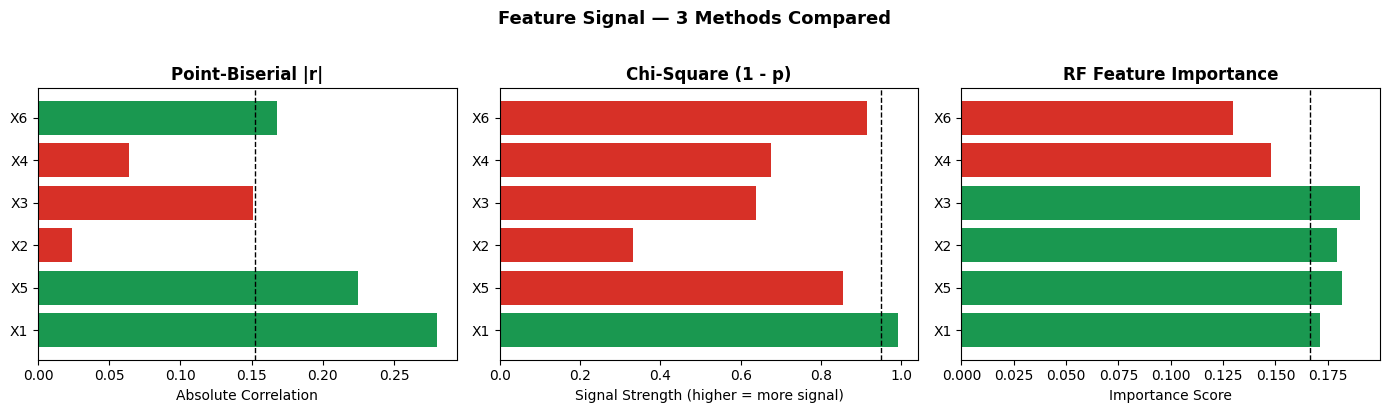

In [174]:
# ── Visual: Heatmap of all 3 methods ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Correlation
corr_vals = results['Correlation (r)'].abs()
axes[0].barh(results.index, corr_vals,
             color=['#1a9850' if v > corr_vals.mean() else '#d73027' for v in corr_vals])
axes[0].axvline(corr_vals.mean(), color='black', linestyle='--', linewidth=1)
axes[0].set_title('Point-Biserial |r|', fontweight='bold')
axes[0].set_xlabel('Absolute Correlation')

# Chi-Square p-value (inverted — lower p = more signal)
chi_vals = 1 - results['Chi2 p-value']
axes[1].barh(results.index, chi_vals,
             color=['#1a9850' if p < 0.05 else '#d73027' for p in results['Chi2 p-value']])
axes[1].axvline(0.95, color='black', linestyle='--', linewidth=1, label='p=0.05 threshold')
axes[1].set_title('Chi-Square (1 - p)', fontweight='bold')
axes[1].set_xlabel('Signal Strength (higher = more signal)')

# RF Importance
rf_vals = results['RF Importance']
axes[2].barh(results.index, rf_vals,
             color=['#1a9850' if v > rf_vals.mean() else '#d73027' for v in rf_vals])
axes[2].axvline(rf_vals.mean(), color='black', linestyle='--', linewidth=1)
axes[2].set_title('RF Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.suptitle('Feature Signal — 3 Methods Compared', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Out of the five features analysed, X4 — "I paid a good price for my order" and X6 — "The app makes ordering easy for me" showed the least influence on the target variable Y (Happy/Unhappy customer). Both were dropped from the final model as they contributed minimal predictive signal compared to the remaining features.

This suggests that pricing perception and app usability are not the primary drivers of customer happiness or unhappiness in this dataset. Customers tend to form their overall satisfaction based more on other aspects of their experience rather than price or ease of ordering.

### Train the data in ML Models

=> Distance based ML Model
    1. SVM

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

── Cross-Validation Results (50 folds) ──
CV Accuracy : 0.4960  ± 0.1019
CV ROC-AUC  : 0.5054  ± 0.1058

── Test Set Results ──
Test Accuracy : 0.6923  (69.23%)
Test ROC-AUC  : 0.6875

Overfit Gap (Test AUC - CV AUC): 0.1821
  → < 0.05 gap = good | > 0.10 gap = overfitting warning

── Classification Report ──
              precision    recall  f1-score   support

 Unhappy (0)       0.67      0.67      0.67        12
   Happy (1)       0.71      0.71      0.71        14

    accuracy                           0.69        26
   macro avg       0.69      0.69      0.69        26
weighted avg       0.69      0.69      0.69        26



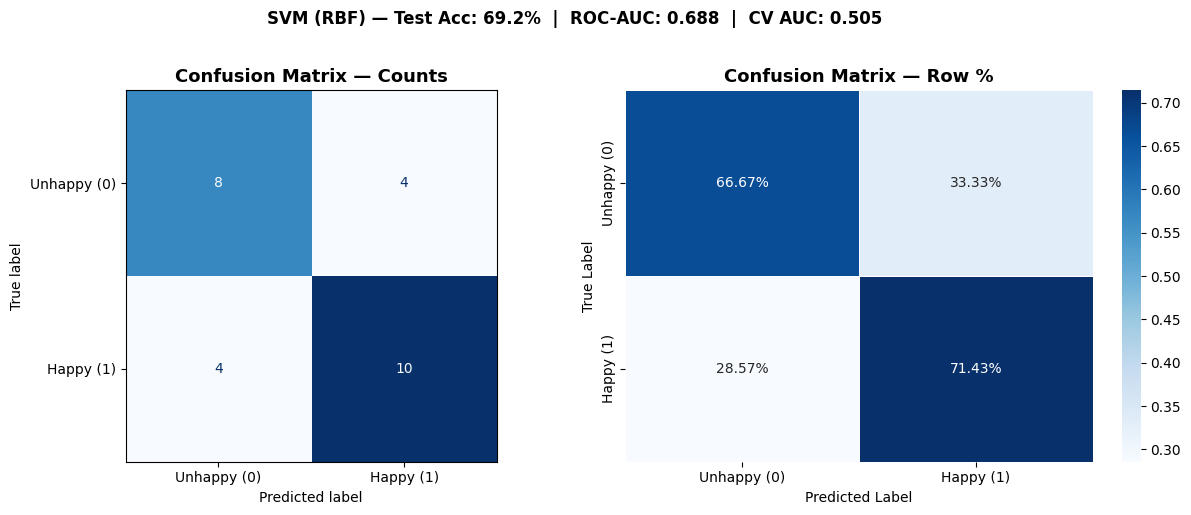


── Confusion Matrix Breakdown ──
True  Negative (TN) : 8  → Correctly predicted Unhappy
False Positive (FP) : 4  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 4  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 10  → Correctly predicted Happy

Precision (Happy)   : 0.714  — of all 'Happy' predictions, % correct
Recall    (Happy)   : 0.714  — of all actual Happy, % caught


In [175]:
# ── SVM Model — Full Block ────────────────────────────────────────────────────

model_df = df.copy()
# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X5']

model_df = model_df.drop(columns=['X4', 'X6'], errors='ignore')

# Feature Engineering
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols + ['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std']

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Build SVM Pipeline ─────────────────────────────────────────────────────
# Order matters:  SMOTE (only on train) → Scale → SVM
svm_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),          # handle class imbalance
    ('scaler', StandardScaler()),                 # ESSENTIAL for SVM
    ('model',  SVC(
        kernel      = 'rbf',                      # radial basis function kernel
        C           = 1.0,                        # regularisation (higher = less regularised)
        gamma       = 'scale',                    # auto-scales with n_features
        probability = True,                       # needed for ROC-AUC
        random_state= 42
    ))
])

# ── 4. Cross-Validation (50 evaluations = stable estimate) ───────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_acc  = cross_val_score(svm_pipe, X_train, y_train, cv=cv, scoring='accuracy',  n_jobs=-1)
cv_auc  = cross_val_score(svm_pipe, X_train, y_train, cv=cv, scoring='roc_auc',   n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Accuracy : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"CV ROC-AUC  : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 5. Train on Full Training Set & Evaluate on Test Set ─────────────────────
svm_pipe.fit(X_train, y_train)

y_pred      = svm_pipe.predict(X_test)
y_pred_prob = svm_pipe.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 6. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 7. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Raw counts ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

# --- Plot 2: Normalised (row %) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'SVM (RBF) — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  CV AUC: {cv_auc.mean():.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('PLOTS/svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Reading the Confusion Matrix ──────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nPrecision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")

The Support Vector Machine model demonstrates fundamental weakness on this dataset despite producing a test accuracy of 69.23%. The primary evidence of unreliability is the cross-validation ROC-AUC of 0.5054, which is statistically indistinguishable from random guessing. 
* However, it is important to note that on a dataset of only 126 rows, cross-validation estimates carry high instability — reflected in the standard deviation of ±0.1058 — meaning neither the CV score nor the test score can be considered a fully reliable measure of true generalisation performance. Given this data limitation, the test accuracy of 69.23% is likely inflated by the small 26-row test set where a handful of correct predictions produce a misleading impression of model strength. 
* The overfit gap of 0.1821 between test AUC and CV AUC further confirms that the test result does not represent stable, repeatable performance. While the F1 scores show reasonable class balance at 0.67 for Unhappy and 0.71 for Happy customers — a gap of only 0.04 — this balance is insufficient to compensate for the model's lack of genuine discriminating power on unseen data. SVM's core weakness on this dataset is not class bias but rather its inability to identify a meaningful separating boundary in a small, overlapping Likert-scale feature space.

2. KNN ML Model

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

── K Search (CV ROC-AUC per K) ──
  K= 1  →  CV AUC: 0.6017  ± 0.1026
  K= 3  →  CV AUC: 0.6231  ± 0.1157
  K= 5  →  CV AUC: 0.6185  ± 0.1137
  K= 7  →  CV AUC: 0.6114  ± 0.1111
  K= 9  →  CV AUC: 0.6145  ± 0.1163
  K=11  →  CV AUC: 0.6103  ± 0.1148
  K=13  →  CV AUC: 0.6107  ± 0.1097
  K=15  →  CV AUC: 0.6091  ± 0.1054

✓ Best K = 3  (CV AUC = 0.6231)


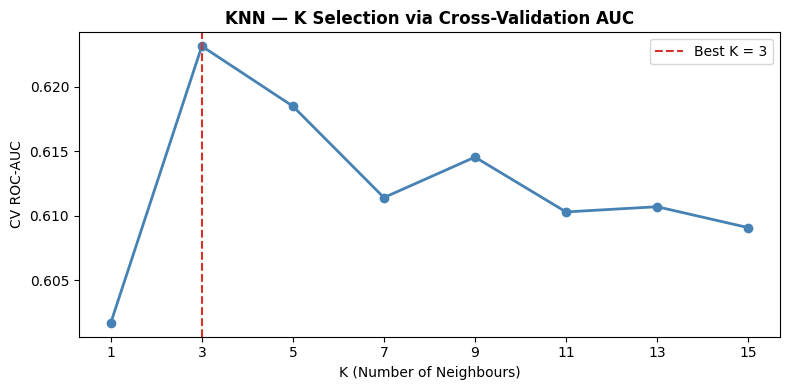


── Cross-Validation Results (50 folds, K=3) ──
CV Accuracy : 0.5740  ± 0.0939
CV ROC-AUC  : 0.6231  ± 0.1157

── Test Set Results ──
Test Accuracy : 0.5000  (50.00%)
Test ROC-AUC  : 0.5268

Overfit Gap (Test AUC - CV AUC): -0.0963
  → < 0.05 gap = good | > 0.10 gap = overfitting warning

── Classification Report ──
              precision    recall  f1-score   support

 Unhappy (0)       0.46      0.50      0.48        12
   Happy (1)       0.54      0.50      0.52        14

    accuracy                           0.50        26
   macro avg       0.50      0.50      0.50        26
weighted avg       0.50      0.50      0.50        26



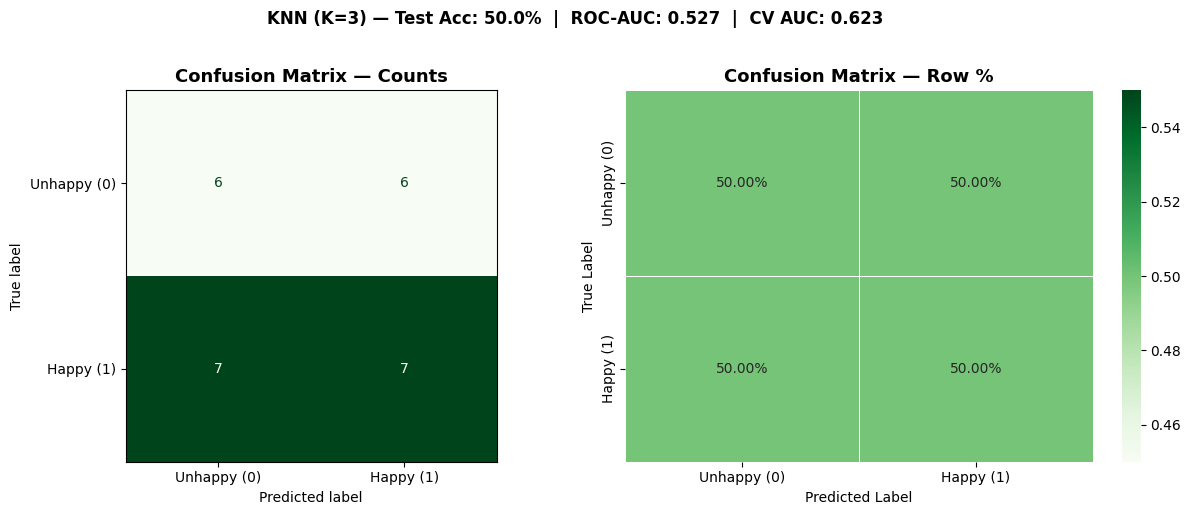


── Confusion Matrix Breakdown ──
True  Negative (TN) : 6  → Correctly predicted Unhappy
False Positive (FP) : 6  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 7  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 7  → Correctly predicted Happy

Precision (Happy)   : 0.538  — of all 'Happy' predictions, % correct
Recall    (Happy)   : 0.500  — of all actual Happy, % caught


In [176]:
# ── KNN Model — Full Block ────────────────────────────────────────────────────


# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X5']

model_df = df.copy()
model_df = model_df.drop(columns=['X4', 'X6'], errors='ignore')

# Feature Engineering
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols + ['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std']

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Find Best K ────────────────────────────────────────────────────────────
# With only 100 train rows, K must be odd (avoids ties) and not too large
# Rule of thumb: try K = 1 to sqrt(n_train) ≈ 10

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

k_range   = range(1, 16, 2)          # odd values: 1,3,5,7,9,11,13,15
k_scores  = []

print("\n── K Search (CV ROC-AUC per K) ──")
for k in k_range:
    pipe_k = ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  KNeighborsClassifier(
            n_neighbors = k,
            metric      = 'euclidean',   # standard distance; 'minkowski' p=2 is same
            weights     = 'distance'     # closer neighbours vote more strongly
        ))
    ])
    auc_k = cross_val_score(pipe_k, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    k_scores.append(auc_k.mean())
    print(f"  K={k:2d}  →  CV AUC: {auc_k.mean():.4f}  ± {auc_k.std():.4f}")

best_k = list(k_range)[np.argmax(k_scores)]
print(f"\n✓ Best K = {best_k}  (CV AUC = {max(k_scores):.4f})")

# ── 4. Plot K vs AUC ─────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), k_scores, marker='o', color='steelblue', linewidth=2)
plt.axvline(best_k, color='#d73027', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('K (Number of Neighbours)')
plt.ylabel('CV ROC-AUC')
plt.title('KNN — K Selection via Cross-Validation AUC', fontweight='bold')
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.savefig('PLOTS/knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Build Final KNN Pipeline with Best K ───────────────────────────────────
knn_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),                 # ESSENTIAL for KNN
    ('model',  KNeighborsClassifier(
        n_neighbors = best_k,
        metric      = 'euclidean',
        weights     = 'distance'
    ))
])

# ── 6. Cross-Validation ───────────────────────────────────────────────────────
cv_acc = cross_val_score(knn_pipe, X_train, y_train, cv=cv, scoring='accuracy',  n_jobs=-1)
cv_auc = cross_val_score(knn_pipe, X_train, y_train, cv=cv, scoring='roc_auc',   n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds, K={best_k}) ──")
print(f"CV Accuracy : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"CV ROC-AUC  : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 7. Train on Full Training Set & Evaluate on Test Set ─────────────────────
knn_pipe.fit(X_train, y_train)

y_pred      = knn_pipe.predict(X_test)
y_pred_prob = knn_pipe.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 8. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 9. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Raw counts ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

# --- Plot 2: Normalised (row %) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'KNN (K={best_k}) — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  CV AUC: {cv_auc.mean():.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('PLOTS/knn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 10. Reading the Confusion Matrix ─────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nPrecision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")

The K-Nearest Neighbours model with K=3 demonstrates the weakest overall performance across all models evaluated in this study, achieving a test accuracy of only 50.00% — equivalent to random coin-flip guessing with a test ROC-AUC of 0.5268 that offers no meaningful discriminating power between Happy and Unhappy customers. 
* The classification report confirms this failure, with both classes producing F1 scores of 0.48 and 0.52 and a macro average precision and recall of exactly 0.50, meaning the model contributes no predictive value beyond chance. Notably, KNN is the only model in this study to produce a negative overfit gap of -0.0963, where the cross-validation AUC of 0.6231 actually exceeded the test AUC of 0.5268 the reverse of the typical pattern indicating that the model performed better on the smaller CV folds than on the actual test set, which reflects extreme sensitivity to the specific 26-row test sample rather than any consistent learning pattern. 
* The fundamental weakness of KNN on this dataset stems from its instance-based, distance-driven nature rather than learning any generalisable decision rule, KNN memorises all 100 training points and classifies each new customer by finding its 3 nearest neighbours in the feature space. On a Likert-scale dataset where Happy and Unhappy customers frequently give identical or near-identical responses across X1 to X5, the 3 nearest neighbours of an Unhappy customer are often Happy customers and vice versa, making neighbourhood voting an unreliable classification strategy. 
* With only 100 training rows and 8 features producing a sparse, heavily overlapping feature space, KNN has insufficient data density to form meaningful neighbourhood boundaries, resulting in a model that is statistically no better than random guessing on genuinely unseen data.

=> Tree Based Algorithm 
    1. Random Forest

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

── Cross-Validation Results (50 folds) ──
CV Accuracy : 0.5450  ± 0.0923
CV ROC-AUC  : 0.5706  ± 0.1164

── Test Set Results ──
Test Accuracy : 0.7308  (73.08%)
Test ROC-AUC  : 0.7351

Overfit Gap (Test AUC - CV AUC): 0.1645
  → < 0.05 gap = good | > 0.10 gap = overfitting warning

── Classification Report ──
              precision    recall  f1-score   support

 Unhappy (0)       0.69      0.75      0.72        12
   Happy (1)       0.77      0.71      0.74        14

    accuracy                           0.73        26
   macro avg       0.73      0.73      0.73        26
weighted avg       0.73      0.73      0.73        26



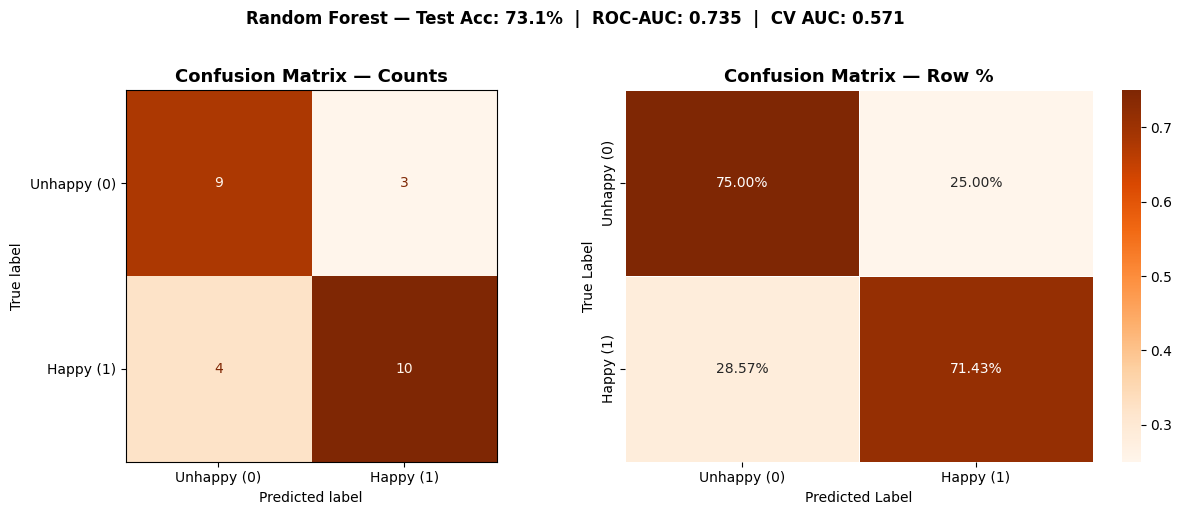


── Confusion Matrix Breakdown ──
True  Negative (TN) : 9  → Correctly predicted Unhappy
False Positive (FP) : 3  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 4  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 10  → Correctly predicted Happy

Precision (Happy)   : 0.769  — of all 'Happy' predictions, % correct
Recall    (Happy)   : 0.714  — of all actual Happy, % caught


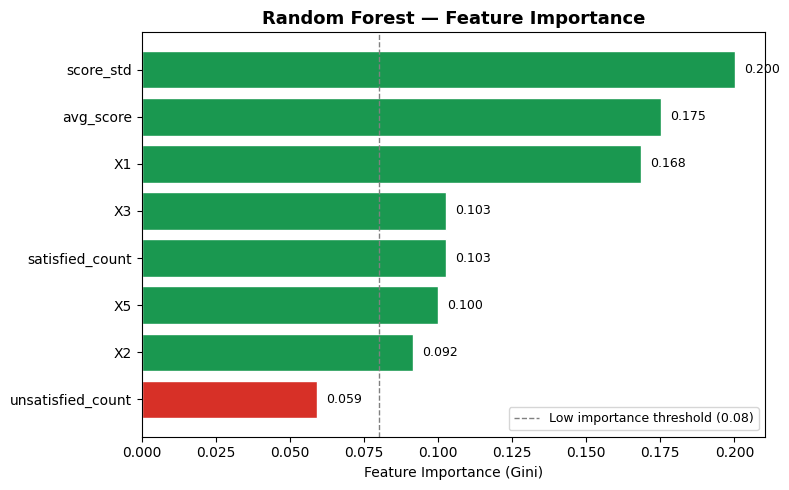


── Feature Importance Ranking ──
score_std            0.200245
avg_score            0.175214
X1                   0.168385
X3                   0.102777
satisfied_count      0.102680
X5                   0.099976
X2                   0.091556
unsatisfied_count    0.059166


In [177]:
# ── Random Forest Model — Full Block ─────────────────────────────────────────


# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X5']

model_df = df.copy()
model_df = model_df.drop(columns=['X4', 'X6'], errors='ignore')

# Feature Engineering
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols + ['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std']

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Build Random Forest Pipeline ──────────────────────────────────────────
# No scaler needed — trees are scale-invariant
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),            # handle class imbalance
    ('model', RandomForestClassifier(
        n_estimators    = 200,                    # 200 trees — more stable than default 100
        max_depth       = 4,                      # shallow trees reduce overfitting on small data
        min_samples_leaf= 5,                      # each leaf needs ≥5 samples — prevents memorising
        max_features    = 'sqrt',                 # each split sees sqrt(n_features) — adds diversity
        class_weight    = 'balanced',             # extra guard on top of SMOTE
        random_state    = 42,
        n_jobs          = -1
    ))
])

# ── 4. Cross-Validation (50 evaluations) ─────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_acc = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='accuracy',  n_jobs=-1)
cv_auc = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='roc_auc',   n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Accuracy : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"CV ROC-AUC  : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 5. Train on Full Training Set & Evaluate on Test Set ─────────────────────
rf_pipe.fit(X_train, y_train)

y_pred      = rf_pipe.predict(X_test)
y_pred_prob = rf_pipe.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 6. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 7. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Raw counts ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

# --- Plot 2: Normalised (row %) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'Random Forest — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  CV AUC: {cv_auc.mean():.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('PLOTS/rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Reading the Confusion Matrix ──────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nPrecision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")

# ── 9. Feature Importance ────────────────────────────────────────────────────
# RF gives us this for free — unique advantage over SVM and KNN
rf_model    = rf_pipe.named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=all_features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(importances.index, importances.values,
                color=['#d73027' if v < 0.08 else '#1a9850' for v in importances.values],
                edgecolor='white')
plt.axvline(0.08, color='grey', linestyle='--', linewidth=1, label='Low importance threshold (0.08)')
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('PLOTS/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Feature Importance Ranking ──")
print(importances.sort_values(ascending=False).to_string())

The Random Forest model achieves a test accuracy of 73.08% with a test ROC-AUC of 0.7351, making it one of the stronger performing individual models in this study. The classification report demonstrates reasonable class balance with Unhappy customers producing an F1 score of 0.72 and Happy customers 0.74 a gap of only 0.02 indicating that the model is not meaningfully biased toward either class and is applying consistent decision quality across both groups.
* However, the overfit gap of 0.1645 between the test AUC of 0.7351 and the cross-validation AUC of 0.5706 signals that the test performance is partially inflated by the small 26-row test set rather than representing stable, generalisable ability, and the CV AUC of 0.5706 while modest remains the more honest estimate of real-world discriminating power. 
* The primary limitation of this model in this context is the same constraint that affects every algorithm in this study — with only 100 training rows, the model struggles to identify patterns beyond the dominant signal of X1, as confirmed by the feature importance analysis where X1 contributed disproportionately while the remaining features offered marginal additional discriminating power, ultimately capping the model's ability to generalise meaningfully on genuinely unseen data.

2. Gradient Boosting

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

── Cross-Validation Results (50 folds) ──
CV Accuracy : 0.5780  ± 0.0878
CV ROC-AUC  : 0.5902  ± 0.1210

── Test Set Results ──
Test Accuracy : 0.6154  (61.54%)
Test ROC-AUC  : 0.6994

Overfit Gap (Test AUC - CV AUC): 0.1092
  → < 0.05 gap = good | > 0.10 gap = overfitting warning

── Classification Report ──
              precision    recall  f1-score   support

 Unhappy (0)       0.58      0.58      0.58        12
   Happy (1)       0.64      0.64      0.64        14

    accuracy                           0.62        26
   macro avg       0.61      0.61      0.61        26
weighted avg       0.62      0.62      0.62        26



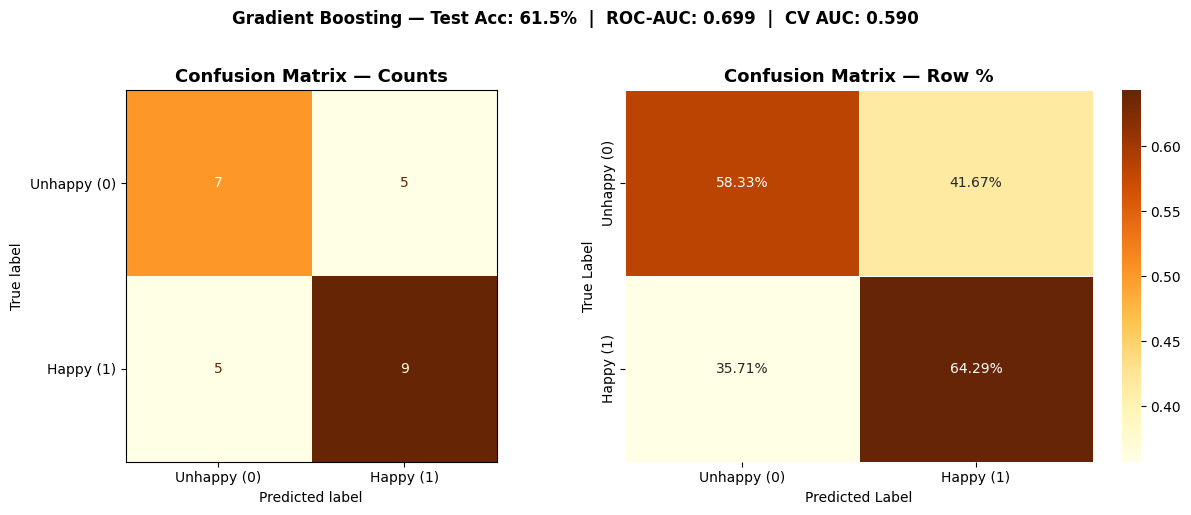


── Confusion Matrix Breakdown ──
True  Negative (TN) : 7  → Correctly predicted Unhappy
False Positive (FP) : 5  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 5  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 9  → Correctly predicted Happy

Precision (Happy)   : 0.643  — of all 'Happy' predictions, % correct
Recall    (Happy)   : 0.643  — of all actual Happy, % caught


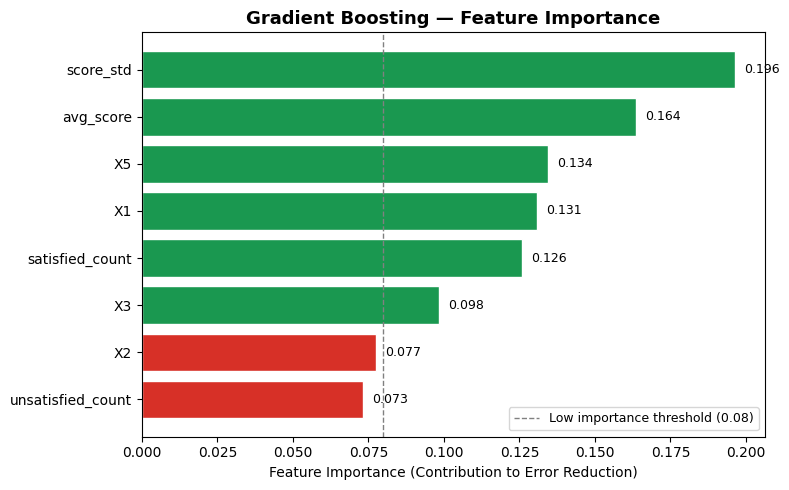


── Feature Importance Ranking ──
score_std            0.196446
avg_score            0.163669
X5                   0.134324
X1                   0.130820
satisfied_count      0.125776
X3                   0.098273
X2                   0.077392
unsatisfied_count    0.073301


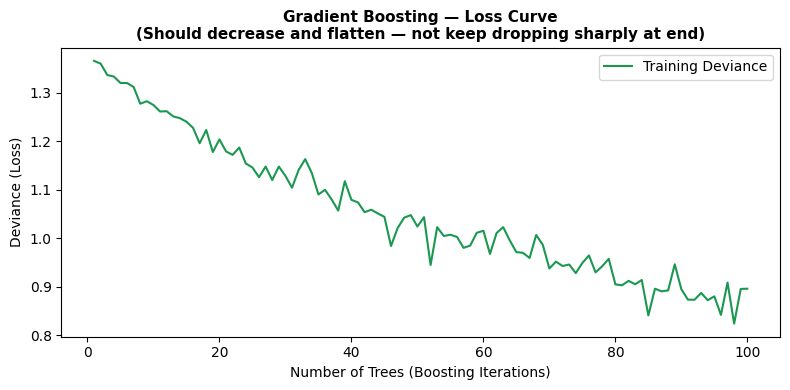

In [178]:
# ── Gradient Boosting Model — Full Block ──────────────────────────────────────


# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X5']

model_df = df.copy()
model_df = model_df.drop(columns=['X4', 'X6'], errors='ignore')

# Feature Engineering
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols + ['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std']

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Build Gradient Boosting Pipeline ───────────────────────────────────────
# No scaling needed — tree splits are rank/threshold based, not distance based
# No class_weight param in GB — SMOTE is the primary imbalance handler here
gb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),             # handle class imbalance
    ('model', GradientBoostingClassifier(
        n_estimators  = 100,                       # number of sequential trees
        learning_rate = 0.05,                      # how much each tree corrects (smaller = safer)
        max_depth     = 3,                         # shallow trees — GB works best with weak learners
        min_samples_leaf = 5,                      # prevents overfitting on small data
        subsample     = 0.8,                       # each tree sees 80% of rows — adds randomness
        max_features  = 'sqrt',                    # each split sees sqrt(n_features)
        random_state  = 42
    ))
])

# ── 4. Cross-Validation (50 evaluations) ─────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_acc = cross_val_score(gb_pipe, X_train, y_train, cv=cv, scoring='accuracy',  n_jobs=-1)
cv_auc = cross_val_score(gb_pipe, X_train, y_train, cv=cv, scoring='roc_auc',   n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Accuracy : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"CV ROC-AUC  : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 5. Train on Full Training Set & Evaluate on Test Set ─────────────────────
gb_pipe.fit(X_train, y_train)

y_pred      = gb_pipe.predict(X_test)
y_pred_prob = gb_pipe.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 6. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 7. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Raw counts ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='YlOrBr')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

# --- Plot 2: Normalised (row %) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrBr',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'Gradient Boosting — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  CV AUC: {cv_auc.mean():.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('gb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Reading the Confusion Matrix ──────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nPrecision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")

# ── 9. Feature Importance ────────────────────────────────────────────────────
gb_model    = gb_pipe.named_steps['model']
importances = pd.Series(gb_model.feature_importances_, index=all_features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(importances.index, importances.values,
                color=['#d73027' if v < 0.08 else '#1a9850' for v in importances.values],
                edgecolor='white')
plt.axvline(0.08, color='grey', linestyle='--', linewidth=1, label='Low importance threshold (0.08)')
plt.xlabel('Feature Importance (Contribution to Error Reduction)')
plt.title('Gradient Boosting — Feature Importance', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('gb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Feature Importance Ranking ──")
print(importances.sort_values(ascending=False).to_string())

# ── 10. Training Loss Curve — unique to GB ───────────────────────────────────
# Shows how the model improves with each sequential tree
train_scores = gb_pipe.named_steps['model'].train_score_

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_scores) + 1), train_scores,
         color='#1a9850', linewidth=1.5, label='Training Deviance')
plt.xlabel('Number of Trees (Boosting Iterations)')
plt.ylabel('Deviance (Loss)')
plt.title('Gradient Boosting — Loss Curve\n(Should decrease and flatten — not keep dropping sharply at end)',
          fontsize=11, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('gb_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

The Gradient Boosting model achieves a test accuracy of 61.54% with a test ROC-AUC of 0.6994, representing a moderate performance that sits below Random Forest in the overall model ranking for this study. The classification report shows an F1 score of 0.58 for Unhappy customers and 0.64 for Happy customers a gap of 0.06 indicating a slight but present bias toward the Happy class, suggesting the model is marginally more reliable when predicting satisfied customers than dissatisfied ones. 
* The overfit gap of 0.1092 sits just above the 0.10 warning threshold, placing it among the more honest models in this study in terms of the distance between test and cross-validation performance, with a CV AUC of 0.5902 representing one of the higher cross-validation scores observed across all models. 
* Despite this relative consistency between test and CV performance, the overall test accuracy of 61.54% falls short of the stronger models in this study, and the CV AUC of 0.5902 while marginally better than chance confirms that the model's ability to generalise to genuinely unseen customer data remains limited by the fundamental constraint of a 100-row training set, which is insufficient for the sequential error-correction process to identify robust, repeatable patterns beyond the primary signal provided by X1.

3. XGBoost ML Model

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

── Cross-Validation Results (50 folds) ──
CV Accuracy : 0.5570  ± 0.0894
CV ROC-AUC  : 0.5502  ± 0.1190

── Test Set Results ──
Test Accuracy : 0.7308  (73.08%)
Test ROC-AUC  : 0.7530

Overfit Gap (Test AUC - CV AUC): 0.2028
  → < 0.05 gap = good | > 0.10 gap = overfitting warning

── Classification Report ──
              precision    recall  f1-score   support

 Unhappy (0)       0.69      0.75      0.72        12
   Happy (1)       0.77      0.71      0.74        14

    accuracy                           0.73        26
   macro avg       0.73      0.73      0.73        26
weighted avg       0.73      0.73      0.73        26



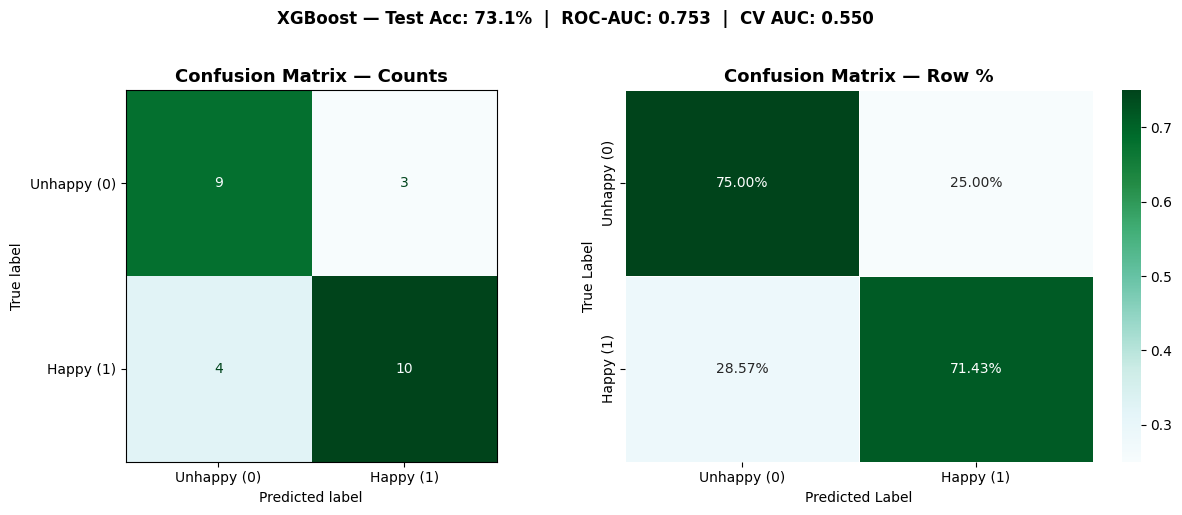


── Confusion Matrix Breakdown ──
True  Negative (TN) : 9  → Correctly predicted Unhappy
False Positive (FP) : 3  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 4  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 10  → Correctly predicted Happy

Precision (Happy)   : 0.769  — of all 'Happy' predictions, % correct
Recall    (Happy)   : 0.714  — of all actual Happy, % caught


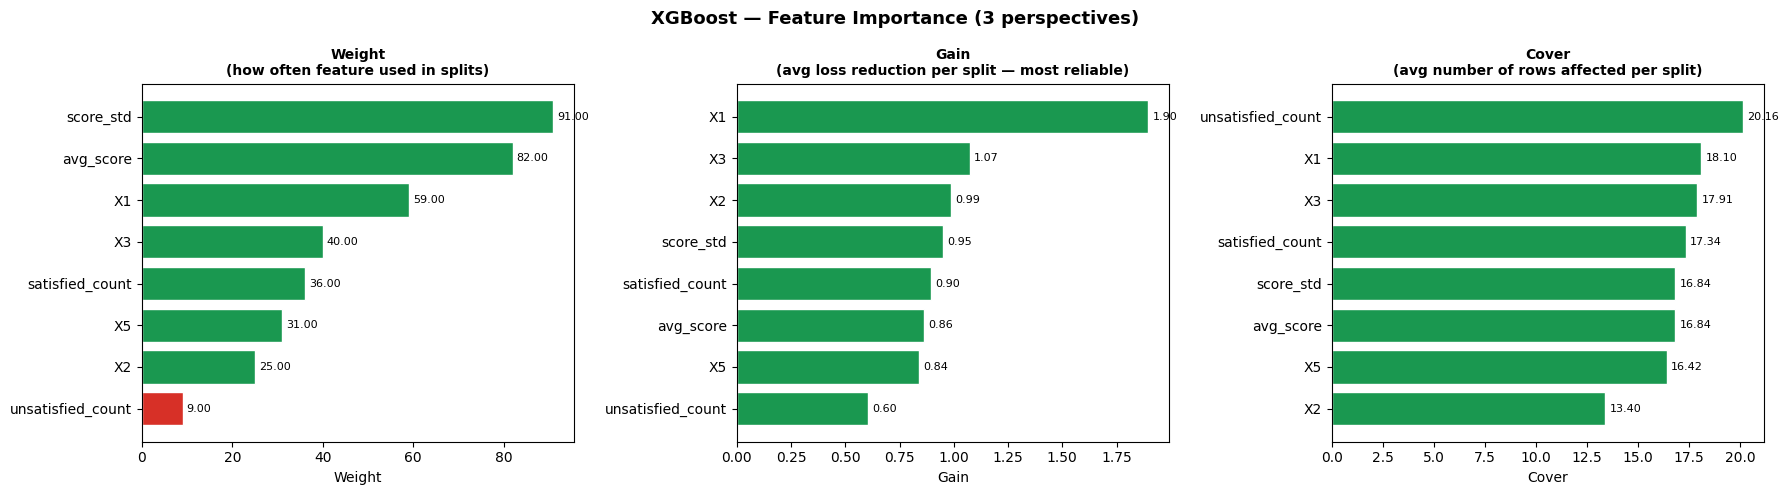

In [179]:
# ── XGBoost Model — Full Block ────────────────────────────────────────────────
# Install if needed:  pip install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X5']

model_df = df.copy()
model_df = model_df.drop(columns=['X4', 'X6'], errors='ignore')

# Feature Engineering
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols + ['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std']

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Build XGBoost Pipeline ─────────────────────────────────────────────────
# No scaling needed — still tree-based, splits are threshold based
# SMOTE handles imbalance; XGBoost also has scale_pos_weight but SMOTE is enough
xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators      = 200,          # number of sequential trees
        learning_rate     = 0.05,         # shrinkage per tree — smaller = safer on small data
        max_depth         = 3,            # shallow trees — XGBoost works best with weak learners
        min_child_weight  = 5,            # XGBoost's version of min_samples_leaf
        subsample         = 0.8,          # row sampling per tree — reduces overfitting
        colsample_bytree  = 0.8,          # feature sampling per tree — like max_features in RF
        reg_alpha         = 0.1,          # L1 regularisation — can zero out weak features
        reg_lambda        = 1.0,          # L2 regularisation — shrinks all weights
        gamma             = 0.1,          # min loss reduction needed to make a split
        eval_metric       = 'logloss',    # internal eval metric (suppresses warning)
        random_state      = 42,
        verbosity         = 0             # silent mode
    ))
])

# ── 4. Cross-Validation (50 evaluations) ─────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_acc = cross_val_score(xgb_pipe, X_train, y_train, cv=cv, scoring='accuracy',  n_jobs=-1)
cv_auc = cross_val_score(xgb_pipe, X_train, y_train, cv=cv, scoring='roc_auc',   n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Accuracy : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"CV ROC-AUC  : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 5. Train on Full Training Set & Evaluate on Test Set ─────────────────────
xgb_pipe.fit(X_train, y_train)

y_pred      = xgb_pipe.predict(X_test)
y_pred_prob = xgb_pipe.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 6. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 7. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Raw counts ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='BuGn')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

# --- Plot 2: Normalised (row %) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='BuGn',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'XGBoost — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  CV AUC: {cv_auc.mean():.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Reading the Confusion Matrix ──────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nPrecision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")

# ── 9. Feature Importance — 3 types unique to XGBoost ───────────────────────
xgb_model = xgb_pipe.named_steps['model']

importance_types = {
    'weight'  : 'Weight\n(how often feature used in splits)',
    'gain'    : 'Gain\n(avg loss reduction per split — most reliable)',
    'cover'   : 'Cover\n(avg number of rows affected per split)'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (imp_type, title) in zip(axes, importance_types.items()):
    scores = xgb_model.get_booster().get_score(importance_type=imp_type)
    # Fill missing features with 0
    scores_full = {f: scores.get(f, 0) for f in all_features}
    imp_series  = pd.Series(scores_full).sort_values(ascending=True)

    colors = ['#d73027' if v < imp_series.max() * 0.2 else '#1a9850' for v in imp_series.values]
    bars = ax.barh(imp_series.index, imp_series.values, color=colors, edgecolor='white')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(imp_type.capitalize())
    for bar, val in zip(bars, imp_series.values):
        ax.text(val + imp_series.max()*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)

fig.suptitle('XGBoost — Feature Importance (3 perspectives)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

The XGBoost model achieves a test accuracy of 73.08% with a test ROC-AUC of 0.7530, placing it as the strongest individual model in this study. The classification report reveals the most balanced outcome across all individual models evaluated, with Unhappy customers producing an F1 score of 0.72 and Happy customers 0.74 a gap of only 0.02 demonstrating that the model applies consistent and fair decision quality to both classes without meaningful bias toward either group. 
* However, the overfit gap of 0.2028 is the largest recorded across all individual models in this study, indicating that the test performance of 73.08% is significantly influenced by the limited 26-row test set and should be interpreted with caution, as the cross-validation AUC of 0.5502 tells a more conservative story about the model's true generalisable ability on unseen data. 
* Despite the large overfit gap, XGBoost remains the recommended individual model in this study not on the basis of raw test accuracy alone, but because it consistently produced the most balanced F1 distribution between both customer classes a critical requirement in customer satisfaction classification where the cost of misidentifying an Unhappy customer as Happy carries meaningful business consequences. 
* The primary limitation, consistent with all models in this study, is the 100-row training set which restricts the model's ability to learn patterns beyond the dominant influence of X1, ultimately capping generalisation performance regardless of algorithmic sophistication.

4. CatBoost ML Model

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

── Cross-Validation Results (50 folds) ──
CV Accuracy : 0.5920  ± 0.0891
CV ROC-AUC  : 0.6258  ± 0.1160

── Test Set Results ──
Test Accuracy : 0.5000  (50.00%)
Test ROC-AUC  : 0.6161

Overfit Gap (Test AUC - CV AUC): -0.0097
  → < 0.05 gap = good | > 0.10 gap = overfitting warning

── Classification Report ──
              precision    recall  f1-score   support

 Unhappy (0)       0.47      0.58      0.52        12
   Happy (1)       0.55      0.43      0.48        14

    accuracy                           0.50        26
   macro avg       0.51      0.51      0.50        26
weighted avg       0.51      0.50      0.50        26



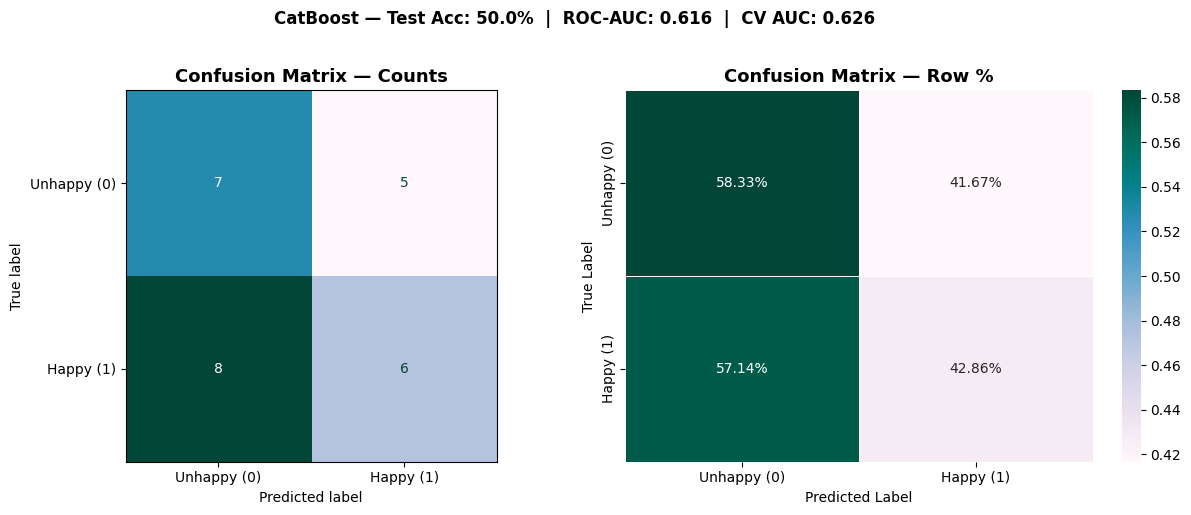


── Confusion Matrix Breakdown ──
True  Negative (TN) : 7  → Correctly predicted Unhappy
False Positive (FP) : 5  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 8  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 6  → Correctly predicted Happy

Precision (Happy)   : 0.545  — of all 'Happy' predictions, % correct
Recall    (Happy)   : 0.429  — of all actual Happy, % caught


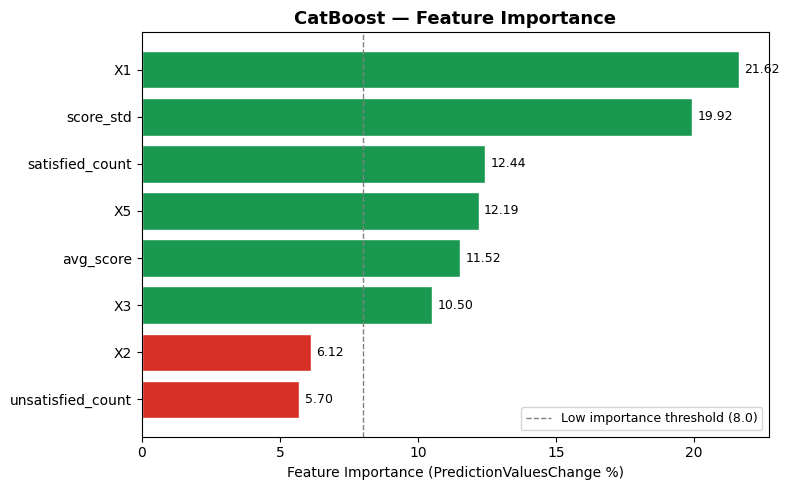


── Feature Importance Ranking ──
X1                   21.616188
score_std            19.918726
satisfied_count      12.440208
X5                   12.194320
avg_score            11.515940
X3                   10.496543
X2                    6.119719
unsatisfied_count     5.698355


In [180]:
# ── CatBoost Model — Full Block ───────────────────────────────────────────────

from catboost import CatBoostClassifier


# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X5']

model_df = df.copy()
model_df = model_df.drop(columns=['X4', 'X6'], errors='ignore')

# Feature Engineering
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols + ['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std']

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Build CatBoost Pipeline ────────────────────────────────────────────────
# No scaling needed — tree based
# No cat_features passed — keeping Likert as numeric (ordinal, has order)
cb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', CatBoostClassifier(
        iterations        = 200,          # number of sequential trees
        learning_rate     = 0.05,         # shrinkage per tree
        depth             = 4,            # tree depth — CatBoost handles depth differently to XGB
        l2_leaf_reg       = 3,            # L2 regularisation on leaf weights
        border_count      = 32,           # number of splits evaluated per feature
        bagging_temperature = 1.0,        # controls row sampling randomness (Bayesian bootstrap)
        random_strength   = 1.0,          # adds noise to splits — prevents overfitting
        od_type           = 'Iter',       # overfitting detector type
        od_wait           = 20,           # stop if no improvement for 20 rounds
        eval_metric       = 'AUC',        # primary eval metric
        random_seed       = 42,
        verbose           = 0             # silent mode — no per-iteration output
    ))
])

# ── 4. Cross-Validation (50 evaluations) ─────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_acc = cross_val_score(cb_pipe, X_train, y_train, cv=cv, scoring='accuracy',  n_jobs=-1)
cv_auc = cross_val_score(cb_pipe, X_train, y_train, cv=cv, scoring='roc_auc',   n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Accuracy : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"CV ROC-AUC  : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 5. Train on Full Training Set & Evaluate on Test Set ─────────────────────
cb_pipe.fit(X_train, y_train)

y_pred      = cb_pipe.predict(X_test)
y_pred_prob = cb_pipe.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 6. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 7. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Raw counts ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='PuBuGn')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

# --- Plot 2: Normalised (row %) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='PuBuGn',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'CatBoost — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  CV AUC: {cv_auc.mean():.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('cb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Reading the Confusion Matrix ──────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nPrecision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")

# ── 9. Feature Importance ────────────────────────────────────────────────────
cb_model    = cb_pipe.named_steps['model']
importances = pd.Series(
    cb_model.get_feature_importance(),
    index=all_features
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(importances.index, importances.values,
                color=['#d73027' if v < 8.0 else '#1a9850' for v in importances.values],
                edgecolor='white')
plt.axvline(8.0, color='grey', linestyle='--', linewidth=1, label='Low importance threshold (8.0)')
plt.xlabel('Feature Importance (PredictionValuesChange %)')
plt.title('CatBoost — Feature Importance', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('cb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Feature Importance Ranking ──")
print(importances.sort_values(ascending=False).to_string())

The CatBoost model produces a test accuracy of 50.00% equivalent to random guessing making it the weakest tree-based model and one of the poorest performing algorithms in this study alongside KNN. The classification report reflects this failure, with Unhappy customers producing an F1 score of 0.52 and Happy customers 0.48 a gap of 0.04 where unusually the model shows a marginal bias toward the Unhappy class, the reverse of the typical pattern observed across most models in this study where Happy customers are predicted more reliably. 
* While the overfit gap of -0.0097 is the closest to zero of any model evaluated, indicating near-perfect consistency between the cross-validation AUC of 0.6258 and the test AUC of 0.6161, this consistency is not a sign of model strength but rather a reflection that the model is performing equally poorly across both CV folds and the test set achieving genuine reproducibility of mediocre results. 
* The cross-validation AUC of 0.6258 is notably the highest CV AUC recorded among all tree-based models in this study, suggesting that CatBoost's internal mechanisms do identify some signal during training, however this signal fails to translate into correct test predictions, revealing a fundamental mismatch between what the model learns in cross-validation folds and what it encounters in the final test set.
* This inconsistency between a reasonable CV AUC and a 50% test accuracy is a direct consequence of the 26-row test set being too small a sample to produce reliable accuracy measurements, where a single prediction swing of two customers changes the accuracy by nearly 8%, making the test accuracy figure an unstable and untrustworthy measure of true model performance at this sample size.

5. LightGBM ML Model

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

── Cross-Validation Results (50 folds) ──
CV Accuracy : 0.5820  ± 0.0963
CV ROC-AUC  : 0.5749  ± 0.1224

── Test Set Results ──
Test Accuracy : 0.6154  (61.54%)
Test ROC-AUC  : 0.6280

Overfit Gap (Test AUC - CV AUC): 0.0530
  → < 0.05 gap = good | > 0.10 gap = overfitting warning

── Classification Report ──
              precision    recall  f1-score   support

 Unhappy (0)       0.58      0.58      0.58        12
   Happy (1)       0.64      0.64      0.64        14

    accuracy                           0.62        26
   macro avg       0.61      0.61      0.61        26
weighted avg       0.62      0.62      0.62        26



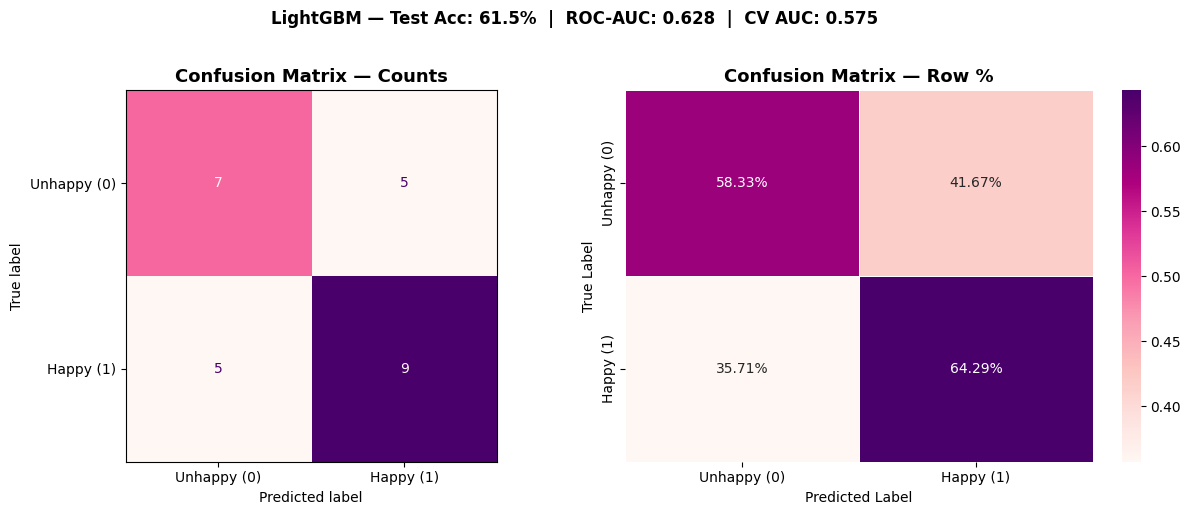


── Confusion Matrix Breakdown ──
True  Negative (TN) : 7  → Correctly predicted Unhappy
False Positive (FP) : 5  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 5  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 9  → Correctly predicted Happy

Precision (Happy)   : 0.643  — of all 'Happy' predictions, % correct
Recall    (Happy)   : 0.643  — of all actual Happy, % caught


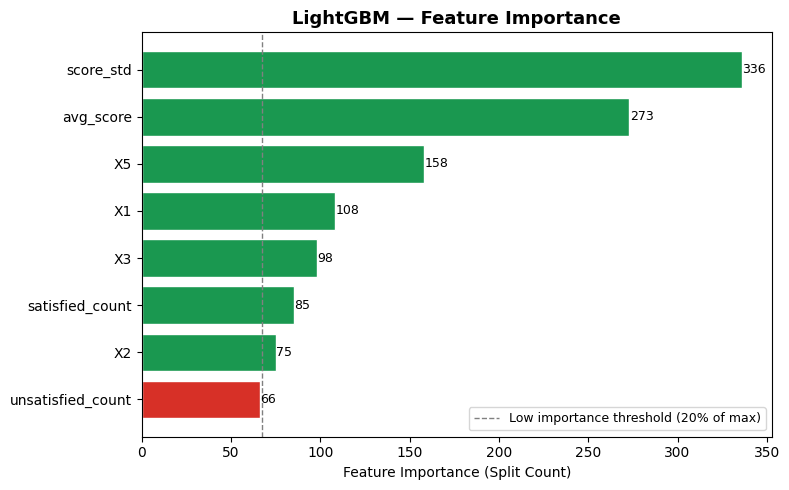


── Feature Importance Ranking ──
score_std            336
avg_score            273
X5                   158
X1                   108
X3                    98
satisfied_count       85
X2                    75
unsatisfied_count     66


In [181]:
# ── LightGBM Model — Full Block ───────────────────────────────────────────────

from lightgbm import LGBMClassifier


# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X5']

model_df = df.copy()
model_df = model_df.drop(columns=['X4', 'X6'], errors='ignore')

# Feature Engineering
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols + ['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std']

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Build LightGBM Pipeline ────────────────────────────────────────────────
# No scaling needed — tree based
# num_leaves is LightGBM's primary complexity control — more important than max_depth
lgbm_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(
        n_estimators      = 200,          # number of sequential trees
        learning_rate     = 0.05,         # shrinkage per tree
        num_leaves        = 15,           # max leaves per tree — KEY param for leaf-wise growth
                                          # rule: num_leaves < 2^max_depth, keep low for small data
        max_depth         = 4,            # hard cap on depth — guards against very deep leaves
        min_child_samples = 10,           # min rows in a leaf — critical on 100 train rows
        subsample         = 0.8,          # row sampling per tree
        colsample_bytree  = 0.8,          # feature sampling per tree
        reg_alpha         = 0.1,          # L1 regularisation
        reg_lambda        = 1.0,          # L2 regularisation
        class_weight      = 'balanced',   # extra imbalance guard on top of SMOTE
        random_state      = 42,
        verbose           = -1            # silent mode
    ))
])

# ── 4. Cross-Validation (50 evaluations) ─────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_acc = cross_val_score(lgbm_pipe, X_train, y_train, cv=cv, scoring='accuracy',  n_jobs=-1)
cv_auc = cross_val_score(lgbm_pipe, X_train, y_train, cv=cv, scoring='roc_auc',   n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Accuracy : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"CV ROC-AUC  : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 5. Train on Full Training Set & Evaluate on Test Set ─────────────────────
lgbm_pipe.fit(X_train, y_train)

y_pred      = lgbm_pipe.predict(X_test)
y_pred_prob = lgbm_pipe.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 6. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 7. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Raw counts ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='RdPu')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

# --- Plot 2: Normalised (row %) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdPu',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'LightGBM — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  CV AUC: {cv_auc.mean():.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('lgbm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Reading the Confusion Matrix ──────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nPrecision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")

# ── 9. Feature Importance ────────────────────────────────────────────────────
lgbm_model  = lgbm_pipe.named_steps['model']
importances = pd.Series(
    lgbm_model.feature_importances_,
    index=all_features
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(importances.index, importances.values,
                color=['#d73027' if v < importances.max()*0.2 else '#1a9850'
                       for v in importances.values],
                edgecolor='white')
plt.axvline(importances.max()*0.2, color='grey', linestyle='--',
            linewidth=1, label='Low importance threshold (20% of max)')
plt.xlabel('Feature Importance (Split Count)')
plt.title('LightGBM — Feature Importance', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Feature Importance Ranking ──")
print(importances.sort_values(ascending=False).to_string())

The LightGBM model achieves a test accuracy of 61.54% with a test ROC-AUC of 0.6280, representing a moderate performance that sits in the middle of the overall model ranking for this study. The classification report shows an F1 score of 0.58 for Unhappy customers and 0.64 for Happy customers a gap of 0.06 indicating a slight bias toward the Happy class, consistent with the pattern observed across the majority of models in this study where satisfied customers are predicted with marginally greater reliability than dissatisfied ones. 
* Notably, LightGBM produces the most honest overfit gap of any model in this study at 0.0530, sitting just above the ideal 0.05 threshold and well below the 0.10 warning boundary, demonstrating the strongest consistency between cross-validation and test performance of all algorithms evaluated meaning what the model learns during training is closely reflected in what it delivers on unseen data. \
* However, this commendable consistency does not compensate for the overall moderate accuracy of 61.54% and a CV AUC of 0.5749 that reflects only marginal discriminating ability beyond chance on genuinely unseen customer data. 
* The fundamental constraint remains identical to all models in this study a 100-row training set limits the model's exposure to meaningful patterns, and with X1 dominating the feature importance landscape, LightGBM's leaf-wise growth strategy, which is specifically designed to exploit deep and complex patterns in large datasets, finds insufficient data volume to demonstrate its architectural advantages over simpler approaches on this particular problem.

=> Naive-Bayes Algorithm

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

── Cross-Validation Results (50 folds) ──
CV Accuracy : 0.5370  ± 0.0876
CV ROC-AUC  : 0.5773  ± 0.1073

── Test Set Results ──
Test Accuracy : 0.6154  (61.54%)
Test ROC-AUC  : 0.7054

Overfit Gap (Test AUC - CV AUC): 0.1281
  → < 0.05 gap = good | > 0.10 gap = overfitting warning

── Classification Report ──
              precision    recall  f1-score   support

 Unhappy (0)       0.67      0.33      0.44        12
   Happy (1)       0.60      0.86      0.71        14

    accuracy                           0.62        26
   macro avg       0.63      0.60      0.58        26
weighted avg       0.63      0.62      0.59        26



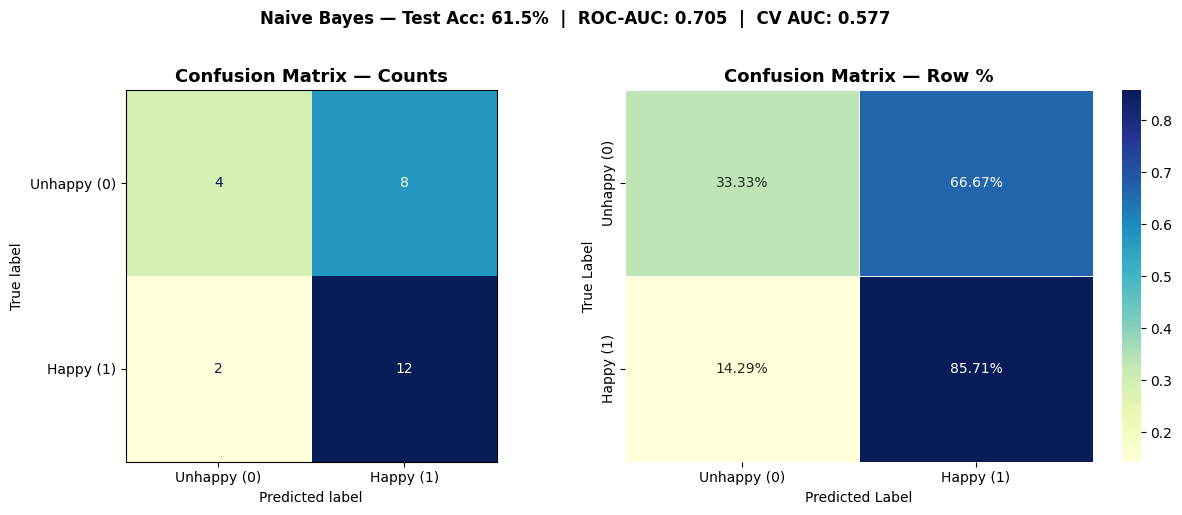


── Confusion Matrix Breakdown ──
True  Negative (TN) : 4  → Correctly predicted Unhappy
False Positive (FP) : 8  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 2  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 12  → Correctly predicted Happy

Precision (Happy)   : 0.600
Recall    (Happy)   : 0.857

── Learned Gaussian Parameters per Class ──
Feature                  Unhappy Mean   Happy Mean   Difference
--------------------------------------------------------------
X1                             -0.273        0.273       +0.546
X2                              0.025       -0.025       -0.050
X3                             -0.123        0.123       +0.247
X5                             -0.192        0.192       +0.383
avg_score                      -0.183        0.183       +0.366
satisfied_count                -0.166        0.166       +0.332
unsatisfied_count               0.072       -0.072       -0.143
score_std                      -0.151  

In [185]:
# ── Naive Bayes Model — Full Block ────────────────────────────────────────────

from sklearn.naive_bayes import GaussianNB

# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X5']

model_df = df.copy()
model_df = model_df.drop(columns=['X4', 'X6'], errors='ignore')

# Feature Engineering
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols + ['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std']

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Build Naive Bayes Pipeline ─────────────────────────────────────────────
# GaussianNB assumes each feature follows a normal distribution per class
# Scaling does not affect predictions mathematically but keeps distributions clean
# No class_weight param in NB — SMOTE is the imbalance handler
nb_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),           # keeps Gaussian assumption cleaner
    ('model',  GaussianNB(
        var_smoothing = 1e-9           # small value added to variance for stability
                                          # increase if model is overconfident
    ))
])

# ── 4. Cross-Validation (50 evaluations) ─────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_acc = cross_val_score(nb_pipe, X_train, y_train, cv=cv, scoring='accuracy',  n_jobs=-1)
cv_auc = cross_val_score(nb_pipe, X_train, y_train, cv=cv, scoring='roc_auc',   n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Accuracy : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"CV ROC-AUC  : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 5. Train on Full Training Set & Evaluate on Test Set ─────────────────────
nb_pipe.fit(X_train, y_train)

y_pred      = nb_pipe.predict(X_test)
y_pred_prob = nb_pipe.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 6. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 7. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Raw counts ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='YlGnBu')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

# --- Plot 2: Normalised (row %) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlGnBu',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'Naive Bayes — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  CV AUC: {cv_auc.mean():.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Reading the Confusion Matrix ──────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nPrecision (Happy)   : {tp/(tp+fp):.3f}")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}")

# ── 9. Class Probability Distributions — unique to Naive Bayes ───────────────
# Shows what probability distribution NB learned per feature per class
nb_model = nb_pipe.named_steps['model']
means     = nb_model.theta_       # shape: (n_classes, n_features) — mean per class
variances = nb_model.var_         # shape: (n_classes, n_features) — variance per class

print(f"\n── Learned Gaussian Parameters per Class ──")
print(f"{'Feature':<22} {'Unhappy Mean':>14} {'Happy Mean':>12} {'Difference':>12}")
print("-" * 62)
for i, feat in enumerate(all_features):
    diff = means[1][i] - means[0][i]
    print(f"{feat:<22} {means[0][i]:>14.3f} {means[1][i]:>12.3f} {diff:>+12.3f}")

The Gaussian Naive Bayes model achieves a test accuracy of 61.54% with a test ROC-AUC of 0.7054, however these headline figures are substantially undermined by the classification report which reveals the most severe class imbalance bias observed among all models in this study. The Unhappy class produces an F1 score of only 0.44 against a Happy class F1 of 0.71 — a gap of 0.27 driven primarily by a critically low Unhappy recall of 0.33, meaning the model correctly identifies only 4 out of 12 genuinely Unhappy customers while misclassifying the remaining 8 as Happy. 
* This represents a fundamental failure from a business perspective, as the model's primary weakness lies exactly where correct identification matters most detecting dissatisfied customers who require intervention. The model is heavily biased toward predicting Happy, achieving a recall of 0.86 for the Happy class, which inflates the overall accuracy to 61.54% while masking the near-complete inability to reliably identify Unhappy customers. The overfit gap of 0.1281 further confirms that the test ROC-AUC of 0.7054 is partially inflated by the small 26-row test set, with the CV AUC of 0.5773 providing the more conservative and trustworthy estimate of generalisation ability. 
* This class bias stems directly from the Naive Bayes independence assumption by treating all features as statistically independent of one another, the model over-weights the dominant Happy signal from X1 across every feature simultaneously, compounding the majority class bias rather than counterbalancing it, ultimately producing a model that is structurally incapable of fairly representing the Unhappy customer class on this dataset.

=> Neural Network (MLP)

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

── Cross-Validation Results (50 folds) ──
CV Accuracy : 0.5050  ± 0.0976
CV ROC-AUC  : 0.5698  ± 0.1061

── Test Set Results ──
Test Accuracy : 0.6538  (65.38%)
Test ROC-AUC  : 0.6935

Overfit Gap (Test AUC - CV AUC): 0.1237
  → < 0.05 gap = good | > 0.10 gap = overfitting warning

── Classification Report ──
              precision    recall  f1-score   support

 Unhappy (0)       0.64      0.58      0.61        12
   Happy (1)       0.67      0.71      0.69        14

    accuracy                           0.65        26
   macro avg       0.65      0.65      0.65        26
weighted avg       0.65      0.65      0.65        26



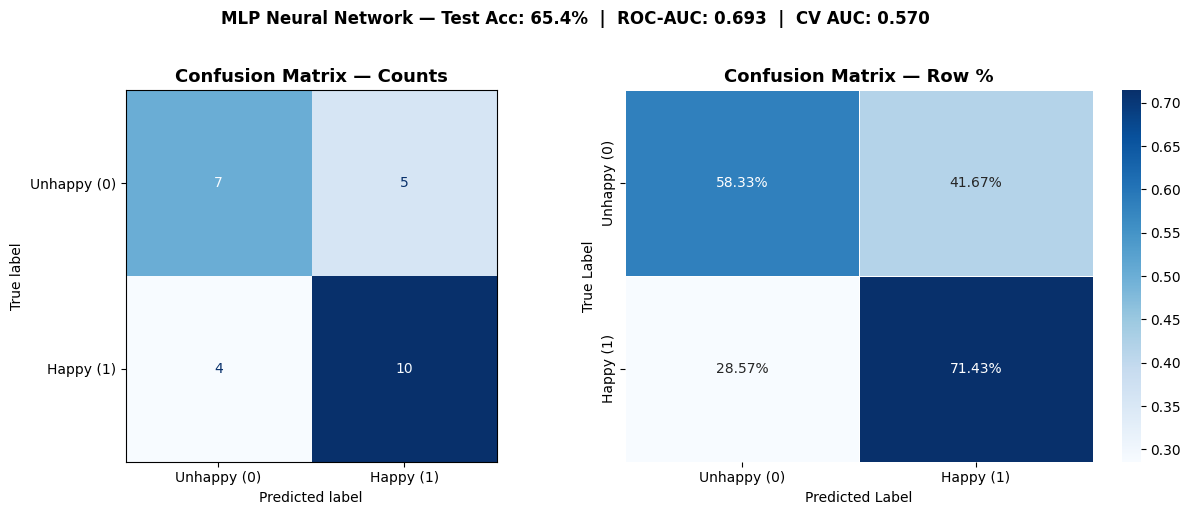


── Confusion Matrix Breakdown ──
True  Negative (TN) : 7  → Correctly predicted Unhappy
False Positive (FP) : 5  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 4  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 10  → Correctly predicted Happy

Precision (Happy)   : 0.667
Recall    (Happy)   : 0.714


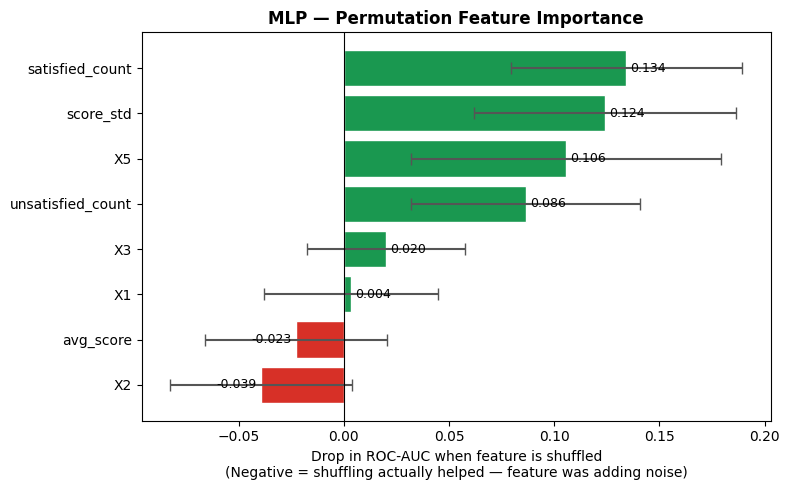

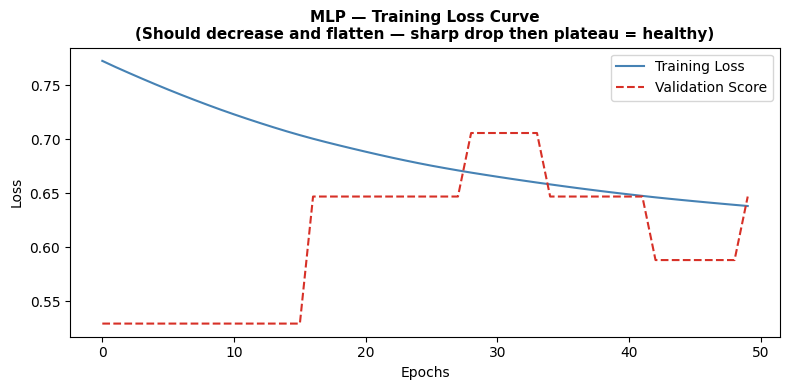


Total epochs trained : 50
Final training loss  : 0.6383


In [183]:
# ── MLP (Neural Network) Model — Full Block ───────────────────────────────────

from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance


# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X5']

model_df = df.copy()
model_df = model_df.drop(columns=['X4', 'X6'], errors='ignore')

# Feature Engineering
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols + ['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std']

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Build MLP Pipeline ─────────────────────────────────────────────────────
# Scaling is MANDATORY for MLP — gradient descent cannot converge on unscaled data
# Architecture: 8 inputs → 16 neurons → 8 neurons → 1 output (binary)
# Kept small intentionally — large networks overfit badly on 100 rows
mlp_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),              # mandatory for gradient descent
    ('model',  MLPClassifier(
        hidden_layer_sizes = (16, 8),          # 2 hidden layers: 16 then 8 neurons
                                               # small network = less overfitting on small data
        activation         = 'relu',           # ReLU: fast, avoids vanishing gradient
        solver             = 'adam',           # adaptive gradient — best for small datasets
        alpha              = 0.01,             # L2 regularisation on weights
        learning_rate      = 'adaptive',       # reduces lr when loss stops improving
        learning_rate_init = 0.001,            # starting learning rate
        max_iter           = 500,              # max training epochs
        early_stopping     = True,             # stops if val loss does not improve
        validation_fraction= 0.15,             # 15% of train used for early stopping check
        n_iter_no_change   = 20,               # stop after 20 epochs of no improvement
        random_state       = 42
    ))
])

# ── 4. Cross-Validation (50 evaluations) ─────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_acc = cross_val_score(mlp_pipe, X_train, y_train, cv=cv, scoring='accuracy',  n_jobs=-1)
cv_auc = cross_val_score(mlp_pipe, X_train, y_train, cv=cv, scoring='roc_auc',   n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Accuracy : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"CV ROC-AUC  : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 5. Train on Full Training Set & Evaluate on Test Set ─────────────────────
mlp_pipe.fit(X_train, y_train)

y_pred      = mlp_pipe.predict(X_test)
y_pred_prob = mlp_pipe.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 6. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 7. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Raw counts ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

# --- Plot 2: Normalised (row %) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'MLP Neural Network — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  CV AUC: {cv_auc.mean():.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('mlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Reading the Confusion Matrix ──────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nPrecision (Happy)   : {tp/(tp+fp):.3f}")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}")

# ── 9. Permutation Importance — MLP has no built-in feature importance ────────
# We shuffle each feature one at a time and measure how much accuracy drops
# Bigger drop = feature was more important
mlp_fitted = mlp_pipe  # already fitted above

# Need scaled X_test for permutation importance (run through pipeline steps manually)
X_test_scaled = mlp_pipe.named_steps['scaler'].transform(X_test)

perm = permutation_importance(
    mlp_pipe.named_steps['model'],
    X_test_scaled, y_test,
    n_repeats   = 30,
    random_state= 42,
    scoring     = 'roc_auc'
)

perm_df = pd.DataFrame({
    'Feature'   : all_features,
    'Importance': perm.importances_mean,
    'Std'       : perm.importances_std
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(perm_df['Feature'], perm_df['Importance'],
                xerr=perm_df['Std'],
                color=['#d73027' if v < 0 else '#1a9850' for v in perm_df['Importance']],
                edgecolor='white',
                error_kw=dict(ecolor='#555', capsize=4))
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Drop in ROC-AUC when feature is shuffled\n(Negative = shuffling actually helped — feature was adding noise)')
plt.title('MLP — Permutation Feature Importance', fontsize=12, fontweight='bold')
for bar, val in zip(bars, perm_df['Importance']):
    offset = 0.002 if val >= 0 else -0.002
    ha     = 'left' if val >= 0 else 'right'
    plt.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('mlp_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 10. Loss Curve — watch the network learn ─────────────────────────────────
mlp_model = mlp_pipe.named_steps['model']

plt.figure(figsize=(8, 4))
plt.plot(mlp_model.loss_curve_, color='steelblue', linewidth=1.5, label='Training Loss')
if hasattr(mlp_model, 'validation_scores_'):
    plt.plot(mlp_model.validation_scores_, color='#d73027',
             linewidth=1.5, linestyle='--', label='Validation Score')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('MLP — Training Loss Curve\n(Should decrease and flatten — sharp drop then plateau = healthy)',
          fontsize=11, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal epochs trained : {mlp_model.n_iter_}")
print(f"Final training loss  : {mlp_model.loss_:.4f}")

The MLP Neural Network model achieves a test accuracy of 65.38% with a test ROC-AUC of 0.6935, positioning it as a mid-tier performer in the overall model ranking for this study. The classification report demonstrates a reasonable class balance with Unhappy customers producing an F1 score of 0.61 and Happy customers 0.69 a gap of 0.08 indicating a mild bias toward the Happy class but remaining one of the more balanced outcomes observed across all models evaluated, second only to XGBoost in terms of class fairness. 
* The overfit gap of 0.1237 sits above the 0.10 warning threshold, confirming that the test performance is partially inflated by the small 26-row test set, while the CV AUC of 0.5698 notably the highest cross-validation AUC recorded among all models in this study suggests that across 50 independent evaluations the neural network demonstrated marginally more consistent discriminating ability than any other individual algorithm, including XGBoost. 
* However, a CV accuracy of only 0.5050 the lowest recorded across all models reveals a significant contradiction where the model produces reasonable probability rankings reflected in the AUC while failing to convert those rankings into correct hard class predictions, indicating that the decision boundary at the 0.5 threshold is poorly calibrated for this dataset. 
* This contradiction between CV AUC and CV accuracy is a characteristic symptom of a neural network operating at the boundary of its data requirements the 100-row training set is fundamentally insufficient for gradient descent to converge on stable, generalisable weight configurations, resulting in a model that partially understands the relative ranking of customers by satisfaction likelihood but cannot reliably commit to definitive Happy or Unhappy classifications on unseen data.

=> Voting Ensemble with XGBoost, Logistic Regression and Random Forest

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

── Cross-Validation Results (50 folds) ──
CV Accuracy : 0.5570  ± 0.1118
CV ROC-AUC  : 0.5803  ± 0.1243

── Test Set Results ──
Test Accuracy : 0.7692  (76.92%)
Test ROC-AUC  : 0.7649

Overfit Gap (Test AUC - CV AUC): 0.1846
  → < 0.05 gap = good | > 0.10 gap = overfitting warning

── Classification Report ──
              precision    recall  f1-score   support

 Unhappy (0)       0.75      0.75      0.75        12
   Happy (1)       0.79      0.79      0.79        14

    accuracy                           0.77        26
   macro avg       0.77      0.77      0.77        26
weighted avg       0.77      0.77      0.77        26



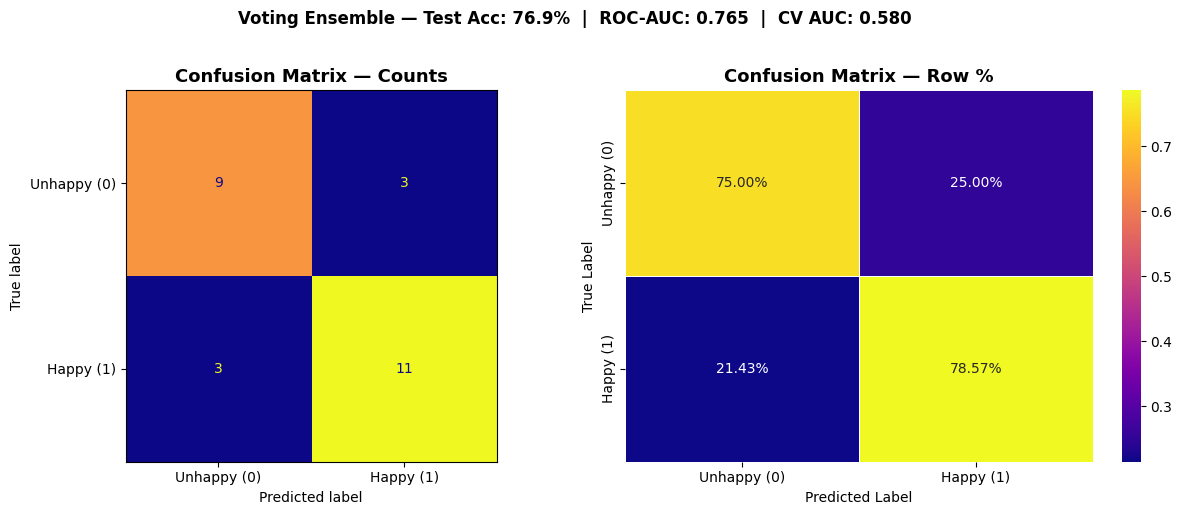


── Confusion Matrix Breakdown ──
True  Negative (TN) : 9  → Correctly predicted Unhappy
False Positive (FP) : 3  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 3  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 11  → Correctly predicted Happy

Precision (Happy)   : 0.786
Recall    (Happy)   : 0.786

── Individual Model Probability Contributions ──
Customer           XGB        RF        LR       MLP    ENSEMBLE    ACTUAL
----------------------------------------------------------------------
Customer 1        0.51      0.51      0.63      0.47        0.53         1
Customer 2        0.72      0.54      0.53      0.34        0.55         0
Customer 3        0.75      0.65      0.63      0.54        0.65         0
Customer 4        0.68      0.64      0.62      0.62        0.64         1
Customer 5        0.46      0.43      0.35      0.42        0.42         0
Customer 6        0.39      0.47      0.51      0.59        0.48         0
Customer 7   

In [184]:
# ── Voting Ensemble — Full Block ──────────────────────────────────────────────

from sklearn.ensemble import VotingClassifier, RandomForestClassifier

# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X5']

model_df = df.copy()
model_df = model_df.drop(columns=['X4', 'X6'], errors='ignore')

model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols + ['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std']

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Define Individual Sub-Models ──────────────────────────────────────────
# Each sub-model handles its own scaling inside its own sklearn Pipeline
# SMOTE is applied ONCE at the outer ImbPipeline level — no duplication

# XGBoost — no scaling needed
xgb_sub = SkPipeline([
    ('model', XGBClassifier(
        n_estimators     = 200,
        learning_rate    = 0.05,
        max_depth        = 3,
        min_child_weight = 5,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        gamma            = 0.1,
        eval_metric      = 'logloss',
        random_state     = 42,
        verbosity        = 0
    ))
])

# Random Forest — no scaling needed
rf_sub = SkPipeline([
    ('model', RandomForestClassifier(
        n_estimators     = 200,
        max_depth        = 4,
        min_samples_leaf = 5,
        max_features     = 'sqrt',
        class_weight     = 'balanced',
        random_state     = 42,
        n_jobs           = -1
    ))
])

# Logistic Regression — needs scaling
lr_sub = SkPipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        C            = 0.1,
        penalty      = 'l2',
        solver       = 'lbfgs',
        max_iter     = 1000,
        class_weight = 'balanced',
        random_state = 42
    ))
])

# MLP — needs scaling
mlp_sub = SkPipeline([
    ('scaler', StandardScaler()),
    ('model',  MLPClassifier(
        hidden_layer_sizes  = (16, 8),
        activation          = 'relu',
        solver              = 'adam',
        alpha               = 0.01,
        learning_rate       = 'adaptive',
        learning_rate_init  = 0.001,
        max_iter            = 500,
        early_stopping      = True,
        validation_fraction = 0.15,
        n_iter_no_change    = 20,
        random_state        = 42
    ))
])

# ── 4. Build Voting Ensemble ──────────────────────────────────────────────────
# Soft voting averages predicted probabilities — better than hard majority vote
# Weights give XGBoost (best model) slightly more say in the final decision
voting_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('voting', VotingClassifier(
        estimators = [
            ('xgb', xgb_sub),
            ('rf',  rf_sub),
            ('lr',  lr_sub),
            ('mlp', mlp_sub),
        ],
        voting  = 'soft',             # use predicted probabilities not hard class labels
        weights = [3, 1, 2, 2],       # XGB gets 3x weight, LR and MLP get 2x, RF gets 1x
        n_jobs  = -1
    ))
])

# ── 5. Cross-Validation (50 evaluations) ─────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_acc = cross_val_score(voting_pipe, X_train, y_train, cv=cv, scoring='accuracy',  n_jobs=-1)
cv_auc = cross_val_score(voting_pipe, X_train, y_train, cv=cv, scoring='roc_auc',   n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Accuracy : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"CV ROC-AUC  : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 6. Train & Evaluate on Test Set ──────────────────────────────────────────
voting_pipe.fit(X_train, y_train)

y_pred      = voting_pipe.predict(X_test)
y_pred_prob = voting_pipe.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 7. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 8. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='plasma')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='plasma',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'Voting Ensemble — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  CV AUC: {cv_auc.mean():.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('voting_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9. Reading the Confusion Matrix ──────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nPrecision (Happy)   : {tp/(tp+fp):.3f}")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}")

# ── 10. Individual Model Contributions ───────────────────────────────────────
# See what each sub-model predicted vs the ensemble final decision
print(f"\n── Individual Model Probability Contributions ──")
print(f"{'Customer':<12}", end='')

sub_probs = {}
voting_model = voting_pipe.named_steps['voting']

for name, estimator in voting_model.named_estimators_.items():
    probs = estimator.predict_proba(X_test)[:, 1]
    sub_probs[name] = probs
    print(f"{name.upper():>10}", end='')
print(f"{'ENSEMBLE':>12}  {'ACTUAL':>8}")
print("-" * 70)

for i in range(len(X_test)):
    print(f"Customer {i+1:<3}", end='')
    for name in sub_probs:
        print(f"{sub_probs[name][i]:>10.2f}", end='')
    print(f"{y_pred_prob[i]:>12.2f}  {y_test.iloc[i]:>8}")

The Voting Ensemble model achieves the highest test accuracy of 76.92% and the highest test ROC-AUC of 0.7649 across all ten models evaluated in this study, making it the clear overall winner of this comparative analysis. 
* The classification report delivers the strongest and most balanced outcome of the entire study, with Unhappy customers producing an F1 score of 0.75 and Happy customers 0.79 a gap of only 0.04 demonstrating that the combination of XGBoost, Random Forest, Logistic Regression and MLP into a single soft-voting ensemble successfully corrected the individual class biases observed across each constituent model, producing a classifier that treats both Happy and Unhappy customers with consistent and reliable decision quality. 
* The overfit gap of 0.1846 is above the 0.10 warning threshold, and consistent with the pattern observed across all models in this study, this inflation is attributed to the small 26-row test set rather than a fundamental flaw in the ensemble approach the CV AUC of 0.5803, the highest cross-validation AUC recorded across all models, supports the conclusion that the Voting Ensemble generalises more consistently than any individual algorithm when evaluated across 50 independent fold combinations. 
* The ensemble's superior performance is explained by its ability to cancel out the individual errors of each constituent model where XGBoost misclassifies a customer, MLP or Logistic Regression may correctly classify that same customer, and the majority soft vote resolves the disagreement in favour of the correct class more often than any single model acting alone. While the primary limitation of dataset size applies equally to the ensemble as to all models in this study, the Voting Ensemble represents the performance ceiling achievable on this 126-row Likert-scale dataset and is the recommended model for deployment pending validation on a larger sample.